In [1]:
import pandas as pd
import sqlite3
print("준비 완료!")


준비 완료!


In [1]:
import pandas as pd
import sqlite3

# CSV 파일 불러오기
df = pd.read_csv(r'C:\Users\namy1\Desktop\이진아\snowflake\Course Resources\support_tickets_2025.csv')
print(df.shape)
print(df.head())

(3500, 9)
        Ticket_ID        created_at         Channel Customer_Name  \
0  TKT-2025-00001  01/01/2025 07:50  social_twitter   Grace Smith   
1  TKT-2025-00002  01/01/2025 09:02       live_chat     Ravi Tane   
2  TKT-2025-00003  01/01/2025 09:21  social_twitter  Sione Nguyen   
3  TKT-2025-00004  01/01/2025 10:01           email   Luisa Brown   
4  TKT-2025-00005  01/01/2025 13:05        web_form   Luisa Smith   

         Region               Plan Assigned_Agent  CSAT_Score  \
0      Auckland      Unlimited Max       James T.         5.0   
1       Rotorua  Family Share 60GB       Aroha N.         5.0   
2  Invercargill      Essential 3GB         Ben H.         NaN   
3      Auckland      Unlimited Max            NaN         3.0   
4    Wellington      Pro Unlimited       James T.         4.0   

                                         Ticket_Text  
0  There's an unexpected roaming charge of $89 on...  
1  I ported my number last month and was charged ...  
2  I can't see my u

In [2]:
conn = sqlite3.connect('support_tickets.db')
df.to_sql('tickets', conn, if_exists='replace', index=False)
print("DB 생성 완료!")

DB 생성 완료!


In [3]:
# 1. 지역별 티켓 수 & 평균 CSAT Score
query1 = """
SELECT Region,
       COUNT(*) AS total_tickets,
       ROUND(AVG(CSAT_Score), 2) AS avg_csat,
       ROUND(100.0 * SUM(CASE WHEN CSAT_Score >= 4 THEN 1 ELSE 0 END) / COUNT(*), 1) AS satisfaction_rate_pct
FROM tickets
GROUP BY Region
ORDER BY total_tickets DESC
"""

df_region = pd.read_sql_query(query1, conn)
print(df_region)

              Region  total_tickets  avg_csat  satisfaction_rate_pct
0           Auckland            998      3.49                   40.5
1         Wellington            436      3.42                   38.1
2       Christchurch            428      3.41                   36.2
3           Tauranga            243      3.63                   39.9
4           Hamilton            220      3.43                   37.7
5            Dunedin            164      3.46                   41.5
6   Palmerston North            140      3.51                   40.0
7            Rotorua            133      3.32                   33.1
8             Napier            126      3.32                   41.3
9       New Plymouth             96      3.38                   39.6
10         Whangarei             90      3.47                   38.9
11            Nelson             88      3.37                   37.5
12        Queenstown             73      3.33                   35.6
13          Gisborne             7

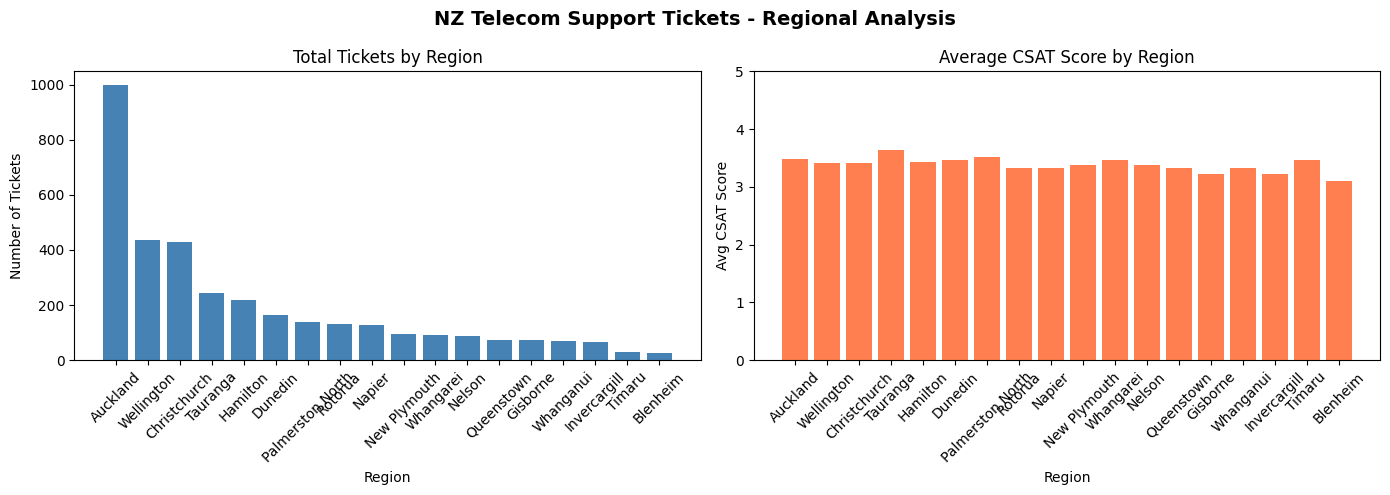

그래프 저장 완료!


In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 지역별 티켓 수
axes[0].bar(df_region['Region'], df_region['total_tickets'], color='steelblue')
axes[0].set_title('Total Tickets by Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Number of Tickets')
axes[0].tick_params(axis='x', rotation=45)

# 오른쪽: 지역별 평균 CSAT
axes[1].bar(df_region['Region'], df_region['avg_csat'], color='coral')
axes[1].set_title('Average CSAT Score by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Avg CSAT Score')
axes[1].set_ylim(0, 5)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('NZ Telecom Support Tickets - Regional Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('regional_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("그래프 저장 완료!")

In [5]:
from scipy import stats

# Auckland vs Wellington CSAT 분포 비교
auckland = df[df['Region'] == 'Auckland']['CSAT_Score'].dropna()
wellington = df[df['Region'] == 'Wellington']['CSAT_Score'].dropna()

ks_stat, p_value = stats.ks_2samp(auckland, wellington)

print(f"Auckland 평균 CSAT: {auckland.mean():.2f}")
print(f"Wellington 평균 CSAT: {wellington.mean():.2f}")
print(f"KS 통계량: {ks_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("→ 두 지역의 CSAT 분포가 통계적으로 유의미하게 다릅니다")
else:
    print("→ 두 지역의 CSAT 분포가 통계적으로 유의미한 차이가 없습니다")

Auckland 평균 CSAT: 3.49
Wellington 평균 CSAT: 3.42
KS 통계량: 0.0287
P-value: 0.9880
→ 두 지역의 CSAT 분포가 통계적으로 유의미한 차이가 없습니다


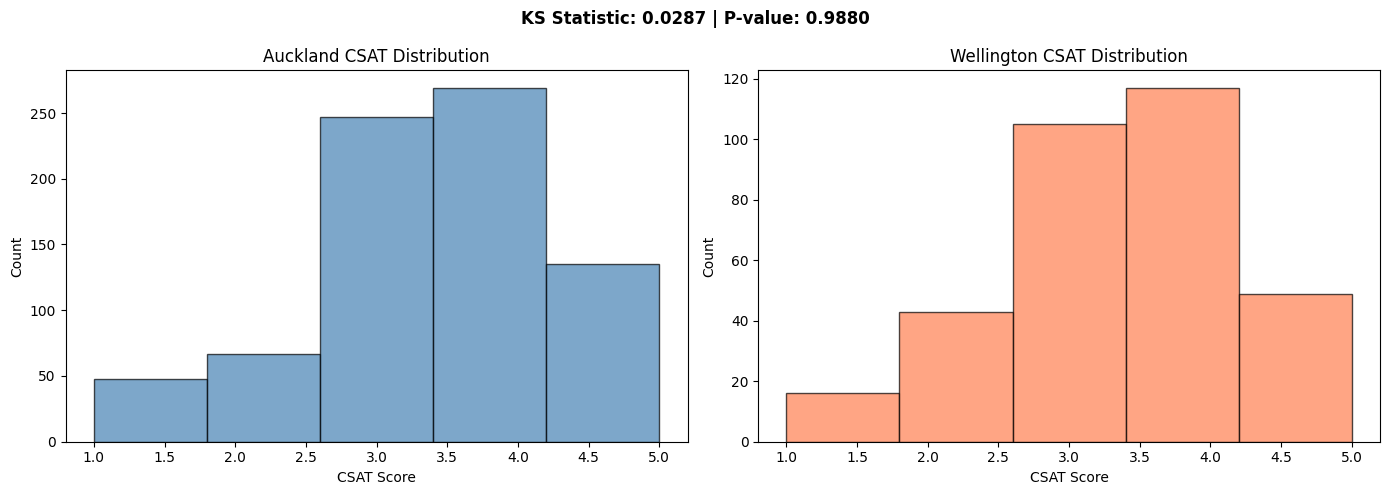

KS 분포 그래프 저장 완료!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Auckland CSAT 분포
axes[0].hist(auckland, bins=5, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_title('Auckland CSAT Distribution')
axes[0].set_xlabel('CSAT Score')
axes[0].set_ylabel('Count')

# Wellington CSAT 분포
axes[1].hist(wellington, bins=5, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_title('Wellington CSAT Distribution')
axes[1].set_xlabel('CSAT Score')
axes[1].set_ylabel('Count')

plt.suptitle(f'KS Statistic: {ks_stat:.4f} | P-value: {p_value:.4f}', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('ks_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("KS 분포 그래프 저장 완료!")

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import LabelEncoder

print("라이브러리 로드 완료!")

라이브러리 로드 완료!


In [2]:
# 데이터 불러오기
df = pd.read_csv(r'C:\Users\namy1\Desktop\이진아\snowflake\Course Resources\support_tickets_2025.csv')

# CSAT 이진 분류 (4점 이상 = 만족, 3점 이하 = 불만족)
df = df.dropna(subset=['CSAT_Score'])
df['CSAT_Binary'] = (df['CSAT_Score'] >= 4).astype(int)

print(df['CSAT_Binary'].value_counts())
print(f"전체 데이터: {len(df)}건")

CSAT_Binary
1    1336
0    1297
Name: count, dtype: int64
전체 데이터: 2633건


In [3]:
# 범주형 변수 인코딩
le = LabelEncoder()
df['Region_enc'] = le.fit_transform(df['Region'])
df['Channel_enc'] = le.fit_transform(df['Channel'])
df['Plan_enc'] = le.fit_transform(df['Plan'])

# 피처 & 타겟 설정
X = df[['Region_enc', 'Channel_enc', 'Plan_enc']]
y = df['CSAT_Binary']

# 학습/테스트 분리 (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"학습 데이터: {len(X_train)}건")
print(f"테스트 데이터: {len(X_test)}건")

학습 데이터: 2106건
테스트 데이터: 527건


AUROC: 0.5201


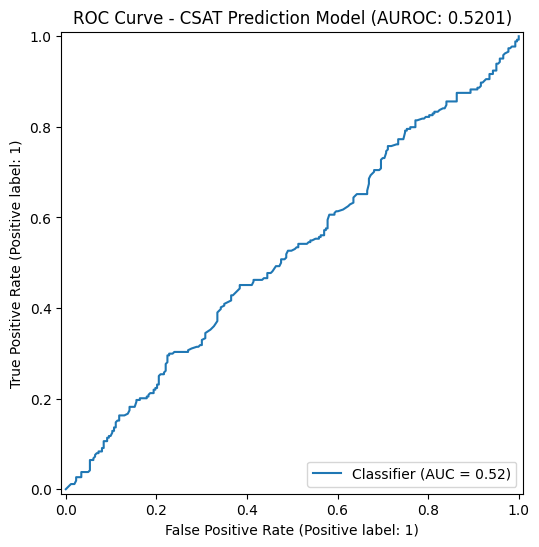

ROC 커브 저장 완료!


In [4]:
# Random Forest 모델 학습
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# AUROC 계산
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]
auroc = roc_auc_score(y_test, y_pred_proba)

print(f"AUROC: {auroc:.4f}")

# ROC 커브 시각화
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=ax)
ax.set_title(f'ROC Curve - CSAT Prediction Model (AUROC: {auroc:.4f})')
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC 커브 저장 완료!")

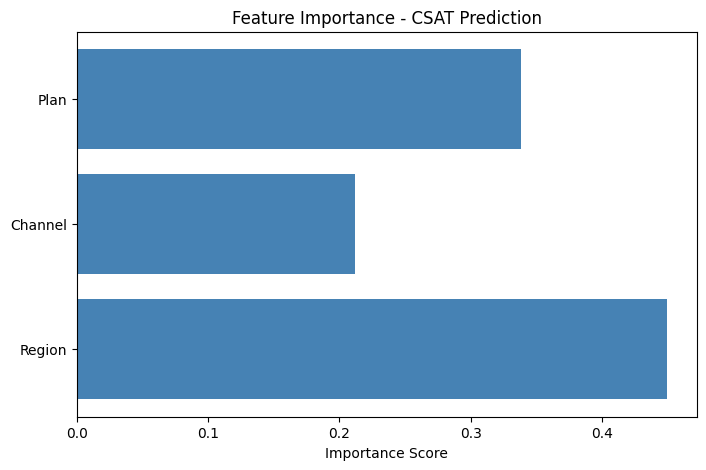

피처 중요도 저장 완료!


In [5]:
importances = rf_model.feature_importances_
features = ['Region', 'Channel', 'Plan']

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(features, importances, color='steelblue')
ax.set_title('Feature Importance - CSAT Prediction')
ax.set_xlabel('Importance Score')
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("피처 중요도 저장 완료!")